# Attempt to estimate airflow from heat transfer variables alongside previous tabletop radiator testing

***Note: this methodology is highly flawed with large error and is merely to get a reasonable guess***

Logic:

We have the following variables at our disposal:

- $\dot{m}_{w}$
- $c_{p,w}$
- $\Delta T_{w,rad}$
- From the 3 variables above, we therefore have $Q_{rad}$ via $Q_{rad} = \dot{m}_{w} c_{p,w} \Delta T_{w,rad}$
- $hA_{rad}$ - This comes from benchtop testing. Ideally, we would use a 3-D lookup table with $\dot{m}_{air}$ and $\Delta T_{w,rad}$, but the lack of sufficient flow rate data currently bottlenecks this. Value is approx 241.
- $T_{air,in}$
- c_{p,air}

With $Q$, we can find $\Delta T_{lm}$ via $Q= hA \Delta T_{lm}$. This allows us to obtain $T_{air,out}$ and, by extension, $\Delta T_{air}$. Finally we can find $\dot{m}_{air}$ via $Q= \dot{m}_{air} \Delta T_{air}$.

### Imports

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Opening df, checking temperatures to set deltas correctly, setting known values

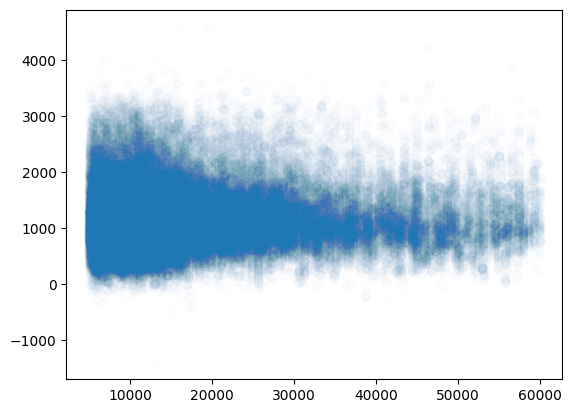

In [49]:
df = pd.read_csv("processed_data/endurance_filtered.csv")
df['left rad delta'] = df['left thermistor'] - df['middle thermistor']
df['motor delta'] = df['left thermistor'] - df['right thermistor']
df['motor inefficiency'] = (5/60) * df['motor delta'] * 4180
df['predicted motor inefficiency'] = df['pack power'] * (1-df['motor efficiency'])
plt.scatter(df['pack power'], df['motor inefficiency'], alpha=0.01)
plt.show()

In [43]:
df['left rad q'] = (5/60) * df['left rad delta'] * 4180
hA = 241
df['T_lm'] = df['left rad q']/hA

df_data = df

### Solving LMTD requires iteration

In [44]:
from scipy.optimize import newton

# function and its derivative
def f(x, *args):
    deltaT1 = args[0]
    Tlm = args[1]
    return (x-deltaT1) / np.log(x/deltaT1) - Tlm

def df(x, *args):
    deltaT1 = args[0]
    return (x * np.log(x / deltaT1) - x + deltaT1) / (x * np.log(x / deltaT1)**2)

In [45]:
def safe_newton(row):
    try:
        return newton(
            f,
            5,
            fprime=df,
            args=(row['left rad delta'], row['T_lm'])
        )
    except Exception:
        return np.nan

df_data['radiator delta air'] = df_data.apply(safe_newton, axis=1)

C:\Users\noahk\AppData\Local\Temp\ipykernel_15008\2520341107.py:7: RuntimeWarning: invalid value encountered in log
  return (x-deltaT1) / np.log(x/deltaT1) - Tlm
C:\Users\noahk\AppData\Local\Temp\ipykernel_15008\2520341107.py:11: RuntimeWarning: invalid value encountered in log
  return (x * np.log(x / deltaT1) - x + deltaT1) / (x * np.log(x / deltaT1)**2)
C:\Users\noahk\AppData\Local\Temp\ipykernel_15008\2520341107.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  return (x-deltaT1) / np.log(x/deltaT1) - Tlm


In [46]:
T_air = 10
c_P_air = 1005
df_data['m_dot_air'] = df_data['left rad q'] / df_data['radiator delta air']
rad_area = 0.23 * 0.128
rho_air = 1.112
df_data['rad air velocity'] = df_data['m_dot_air'] / (rad_area * rho_air)
df_data.to_csv('processed_data/air-flow-estimation.csv', index=False)

In [47]:
df_data[['m_dot_air', 'left rad q', 'radiator delta air']].describe()


,m_dot_air,left rad q,radiator delta air
count,90578.000000,90753.000000,90578.000000
mean,173.576188,1224.786001,7.069394
std,1.525973,569.420588,3.268622
min,0.000000,-542.536149,0.765659
25%,173.589604,821.556036,4.732778
50%,173.589604,1119.919724,6.465389
75%,173.589604,1528.629655,8.807042
max,173.589604,4637.003541,26.712450
